# Análisis y visualización de señales EMG - BITalino (7 movimientos)

El objetivo convertir las señales crudas (ADC) medidas con el BITalino a su unidad física (EMG en mV) y visualizarlas, separando los 7 movimientos en sus 3 grupos:

1. **Reposo** → 1 archivo
2. **Movimiento leve** → 3 archivos
3. **Movimiento vs fuerza contraria** → 3 archivos

Librería usada para leer y convertir las señales: [`opensignalsreader`](https://github.com/PGomes92/opensignalsreader).

**Importante sobre los archivos `.txt`:** este notebook asume que tus 7 archivos `.txt` de OpenSignals están guardados en **Google Drive, en la misma carpeta donde está este notebook**. La celda siguiente monta tu Google Drive (si usas Google Colab) y ubica automáticamente esa carpeta.

Si en cambio estás corriendo este notebook en Jupyter local (no Colab) con los `.txt` en la misma carpeta del `.ipynb`, puedes saltarte la celda de montaje de Drive: la carpeta de datos por defecto (`.`) ya apunta a la carpeta actual.

In [20]:
# Instalar dependencias (solo la primera vez que corras el notebook)
!pip install -q opensignalsreader matplotlib numpy

## 1. Montar Google Drive y ubicar la carpeta de datos

En **Google Colab**, ejecuta la siguiente celda: montará tu Drive y buscará automáticamente la carpeta donde está este notebook (usando el path de Drive). Colocar los 7 archivos `.txt` en esa misma carpeta.

Asegurarse de que los `.txt` estén junto al `.ipynb` y deja `CARPETA_DATOS = "."`.

In [21]:
import os

# Carpeta de datos por defecto: la misma carpeta donde está el notebook
CARPETA_DATOS = "."

try:
    # Esto solo funciona dentro de Google Colab
    from google.colab import drive
    drive.mount('/content/drive')

    # --------------------------------------------------------------
    CARPETA_DATOS = "/content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones LAB3 (EMG)/Abductor pollicis brevis (thumb)"

    print(f"Google Drive montado. Carpeta de datos configurada en: {CARPETA_DATOS}")

except ImportError:
    print("No se detectó Google Colab. Se usará la carpeta local del notebook (.)")

print("Contenido de la carpeta de datos:")
if os.path.isdir(CARPETA_DATOS):
    print(os.listdir(CARPETA_DATOS))
else:
    print(f"  [!] La carpeta '{CARPETA_DATOS}' todavía no existe o la ruta es incorrecta.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montado. Carpeta de datos configurada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones LAB3 (EMG)/Abductor pollicis brevis (thumb)
Contenido de la carpeta de datos:
['PRUEBA 02 ABDUCTOR OFICIAL.h5', 'MOV LEVE ABDUCTOR 01.h5', 'MOV LEVE ABDUCTOR 02.h5', 'MOV LEVE ABDUCTOR 03.h5', 'OPOSICION ABDUCTOR 01.h5', 'OPOSICION ABDUCTOR 02.h5', 'OPOSICION ABDUCTOR 03.h5', 'PRUEBA 02 ABDUCTOR OFICIAL.txt', 'MOV LEVE ABDUCTOR 01.txt', 'MOV LEVE ABDUCTOR 02.txt', 'MOV LEVE ABDUCTOR 03.txt', 'OPOSICION ABDUCTOR 01.txt', 'OPOSICION ABDUCTOR 02.txt', 'OPOSICION ABDUCTOR 03.txt', 'analisis_bitalino_pulgar.ipynb', 'figuras_bitalino2']


## 2. Configuración de los 7 archivos

Reemplaza los nombres referenciales por los nombres reales de tus `.txt` una vez que los subas a Drive. Se mantienen agrupados según tu diseño experimental.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from opensignalsreader import OpenSignalsReader

%matplotlib inline

# Nombres de archivo (referenciales por ahora). Reemplázalos por los reales.
ARCHIVOS = {
    "Movimiento con fuerza contraria": [
        "OPOSICION ABDUCTOR 01.txt",
        "OPOSICION ABDUCTOR 02.txt",
        "OPOSICION ABDUCTOR 03.txt",
    ],
    "Movimiento leve": [
        "MOV LEVE ABDUCTOR 01.txt",
        "MOV LEVE ABDUCTOR 02.txt",
        "MOV LEVE ABDUCTOR 03.txt",
    ],
    "Reposo": [
        "PRUEBA 02 ABDUCTOR OFICIAL.txt",
    ],
}

# Único sensor usado en las mediciones: EMG
CANAL = "EMG"
UNIDAD = "mV"

# Carpeta donde se guardarán las figuras generadas (dentro de la misma carpeta de datos)
CARPETA_SALIDA = os.path.join(CARPETA_DATOS, "figuras_bitalino2")

# Si True, se grafica también la señal cruda (ADC) superpuesta
MOSTRAR_CRUDO = False

## Instalacion de open signals

In [23]:
pip install opensignalsreader

## 3. Funciones de carga y graficado

In [24]:
def cargar_senal(ruta_archivo, canal):
    """
    Carga un archivo OpenSignals/BITalino y devuelve:
        t        -> vector de tiempo (s)
        senal    -> señal EMG convertida a mV
        senal_cr -> señal cruda (ADC)
        fs       -> frecuencia de muestreo (Hz)

    Si el archivo aún no existe, devuelve None para no interrumpir el
    resto del notebook mientras vas agregando tus .txt uno por uno.
    """
    if not os.path.isfile(ruta_archivo):
        print(f"  [!] No se encontró el archivo: {ruta_archivo} (aún no agregado)")
        return None

    acq = OpenSignalsReader(ruta_archivo)

    senal = acq.signal(canal)      # señal convertida a mV
    senal_cr = acq.raw(canal)      # señal cruda (valor ADC)
    fs = acq.sampling_rate         # frecuencia de muestreo (Hz)

    t = np.arange(len(senal)) / fs

    return t, senal, senal_cr, fs

In [25]:
def graficar_grupo(nombre_grupo, lista_archivos, canal, carpeta_datos,
                    mostrar_crudo=False, carpeta_salida=None):
    """
    Grafica de todas las señales de un grupo en una sola figura, un subplot por archivo.
    """
    n = len(lista_archivos)
    fig, ejes = plt.subplots(n, 1, figsize=(10, 3 * n), sharex=False)

    if n == 1:
        ejes = [ejes]

    fig.suptitle(f"{nombre_grupo} - EMG", fontsize=14, fontweight="bold")

    for ax, nombre_archivo in zip(ejes, lista_archivos):
        ruta = os.path.join(carpeta_datos, nombre_archivo)
        resultado = cargar_senal(ruta, canal)

        if resultado is None:
            ax.set_title(f"{nombre_archivo} (pendiente de agregar)")
            ax.text(0.5, 0.5, "Archivo no encontrado", ha="center", va="center",
                    transform=ax.transAxes, color="gray")
            continue

        t, senal, senal_cr, fs = resultado

        ax.plot(t, senal, linewidth=0.8)
        ax.set_title(nombre_archivo)
        ax.set_xlabel("Tiempo (s)")
        ax.set_ylabel(f"EMG ({UNIDAD})")
        ax.grid(alpha=0.3)

        if mostrar_crudo:
            ax2 = ax.twinx()
            ax2.plot(t, senal_cr, color="orange", alpha=0.4, linewidth=0.6)
            ax2.set_ylabel("Valor crudo (ADC)", color="orange")

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if carpeta_salida:
        os.makedirs(carpeta_salida, exist_ok=True)
        nombre_fig = nombre_grupo.lower().replace(" ", "_") + ".png"
        ruta_fig = os.path.join(carpeta_salida, nombre_fig)
        fig.savefig(ruta_fig, dpi=150)
        print(f"  -> Figura guardada en: {ruta_fig}")

    return fig

In [26]:
def graficar_comparacion_general(archivos_dict, canal, carpeta_datos,
                                  carpeta_salida=None):

    fig, ax = plt.subplots(figsize=(10, 5))
    colores = {"Reposo": "tab:green",
               "Movimiento leve": "tab:blue",
               "Movimiento con fuerza contraria": "tab:red"}

    for nombre_grupo, lista_archivos in archivos_dict.items():
        for nombre_archivo in lista_archivos:
            ruta = os.path.join(carpeta_datos, nombre_archivo)
            resultado = cargar_senal(ruta, canal)
            if resultado is None:
                continue
            t, senal, senal_cr, fs = resultado
            ax.plot(t, senal, label=f"{nombre_grupo} - {nombre_archivo}",
                    color=colores.get(nombre_grupo), alpha=0.7, linewidth=0.8)

    ax.set_title(f"Comparación general - EMG")
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel(f"EMG ({UNIDAD})")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.3)
    plt.tight_layout()

    if carpeta_salida:
        os.makedirs(carpeta_salida, exist_ok=True)
        ruta_fig = os.path.join(carpeta_salida, "comparacion_general.png")
        fig.savefig(ruta_fig, dpi=150)
        print(f"  -> Figura guardada en: {ruta_fig}")

    return fig

## 4. Funciones de análisis en el dominio de la frecuencia (FFT)

In [27]:
def calcular_fft_db(senal, fs):
    """
    Calcula la FFT de una señal y devuelve la magnitud en dB.
    """
    N = len(senal)
    yf = np.fft.fft(senal)
    xf = np.fft.fftfreq(N, 1/fs)[:N//2]
    # Evitar log10 de cero o valores muy cercanos a cero
    magnitude_db = 20 * np.log10(np.abs(yf[0:N//2]) + 1e-10) # Añadir un pequeño valor para evitar log(0)
    return xf, magnitude_db

In [28]:
def graficar_fft_grupo(nombre_grupo, lista_archivos, canal, carpeta_datos, carpeta_salida=None):
    """
    Grafica las FFT en dB de todas las señales de un grupo.
    """
    n = len(lista_archivos)
    fig, ejes = plt.subplots(n, 1, figsize=(10, 3 * n), sharex=False)

    if n == 1:
        ejes = [ejes]

    fig.suptitle(f"{nombre_grupo} - FFT (dB)", fontsize=14, fontweight="bold")

    for ax, nombre_archivo in zip(ejes, lista_archivos):
        ruta = os.path.join(carpeta_datos, nombre_archivo)
        resultado = cargar_senal(ruta, canal)

        if resultado is None:
            ax.set_title(f"{nombre_archivo} (pendiente de agregar)")
            ax.text(0.5, 0.5, "Archivo no encontrado", ha="center", va="center",
                    transform=ax.transAxes, color="gray")
            continue

        t, senal, senal_cr, fs = resultado
        xf, magnitude_db = calcular_fft_db(senal, fs)

        ax.plot(xf, magnitude_db, linewidth=0.8)
        ax.set_title(f"{nombre_archivo} - FFT")
        ax.set_xlabel("Frecuencia (Hz)")
        ax.set_ylabel("Magnitud (dB)")
        ax.grid(alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if carpeta_salida:
        os.makedirs(carpeta_salida, exist_ok=True)
        nombre_fig = nombre_grupo.lower().replace(" ", "_") + "_fft.png"
        ruta_fig = os.path.join(carpeta_salida, nombre_fig)
        fig.savefig(ruta_fig, dpi=150)
        print(f"  -> Figura FFT guardada en: {ruta_fig}")

    return fig

In [29]:
def graficar_fft_comparacion_general(archivos_dict, canal, carpeta_datos, carpeta_salida=None):
    """
    Genera una figura con las FFT en dB de todos los grupos superpuestas.
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    colores = {"Reposo": "tab:green",
               "Movimiento leve": "tab:blue",
               "Movimiento con fuerza contraria": "tab:red"}

    for nombre_grupo, lista_archivos in archivos_dict.items():
        for nombre_archivo in lista_archivos:
            ruta = os.path.join(carpeta_datos, nombre_archivo)
            resultado = cargar_senal(ruta, canal)
            if resultado is None:
                continue
            t, senal, senal_cr, fs = resultado
            xf, magnitude_db = calcular_fft_db(senal, fs)
            ax.plot(xf, magnitude_db, label=f"{nombre_grupo} - {nombre_archivo}",
                    color=colores.get(nombre_grupo), alpha=0.7, linewidth=0.8)

    ax.set_title("Comparación general - FFT (dB)")
    ax.set_xlabel("Frecuencia (Hz)")
    ax.set_ylabel("Magnitud (dB)")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.3)
    plt.tight_layout()

    if carpeta_salida:
        os.makedirs(carpeta_salida, exist_ok=True)
        ruta_fig = os.path.join(carpeta_salida, "comparacion_general_fft.png")
        fig.savefig(ruta_fig, dpi=150)
        print(f"  -> Figura FFT guardada en: {ruta_fig}")

    return fig

## 5. Ejecutar: graficar los 3 grupos + comparación general (dominio del tiempo y frecuencia)


Grupo: Movimiento con fuerza contraria (3 archivo(s))
  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones LAB3 (EMG)/Abductor pollicis brevis (thumb)/figuras_bitalino2/movimiento_con_fuerza_contraria.png


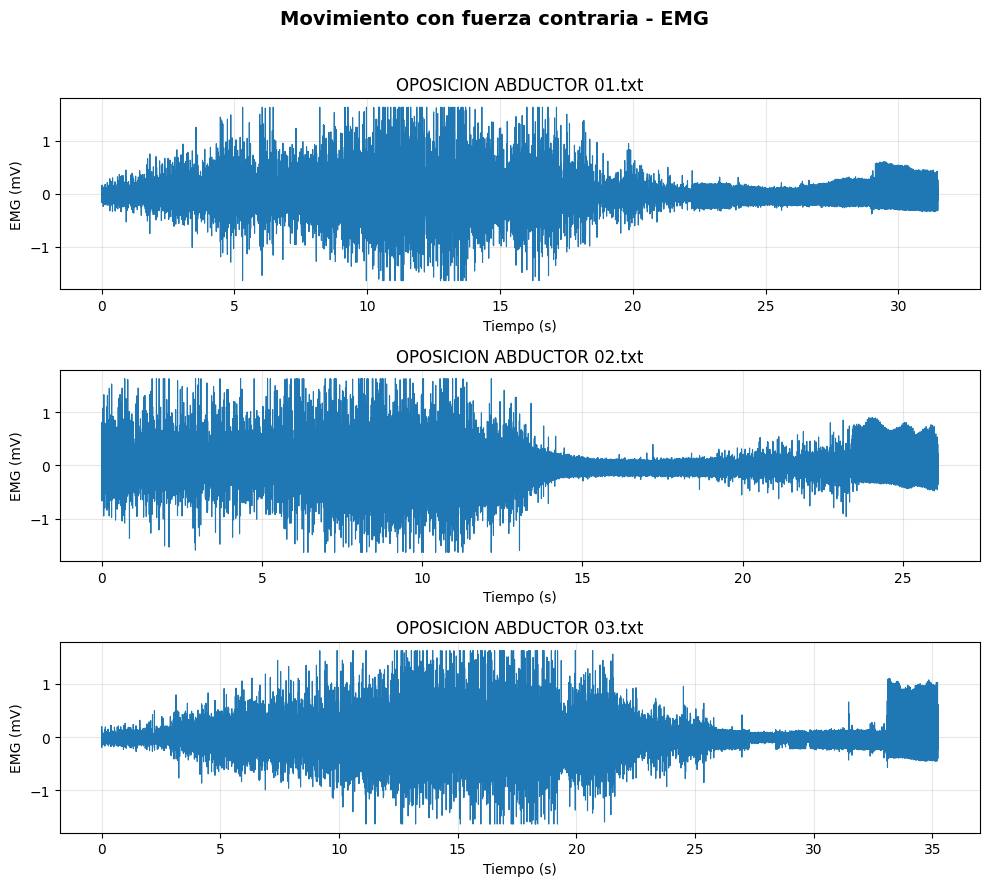


Grupo: Movimiento leve (3 archivo(s))
  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones LAB3 (EMG)/Abductor pollicis brevis (thumb)/figuras_bitalino2/movimiento_leve.png


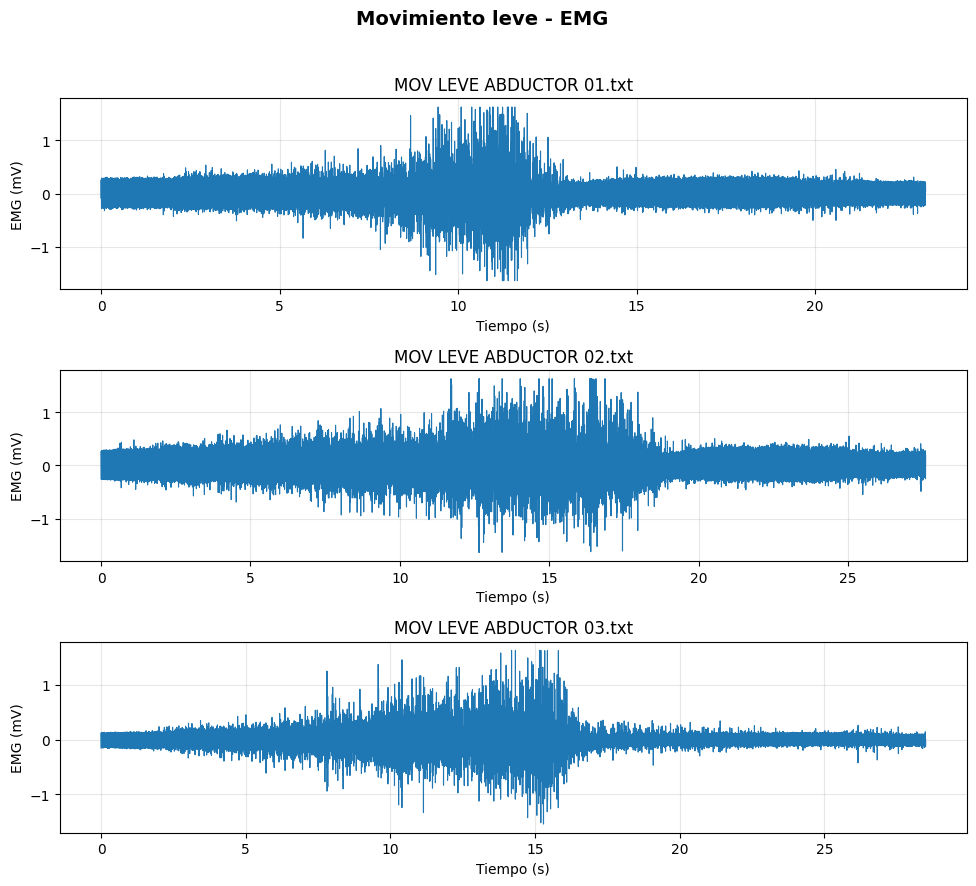


Grupo: Reposo (1 archivo(s))
  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones LAB3 (EMG)/Abductor pollicis brevis (thumb)/figuras_bitalino2/reposo.png


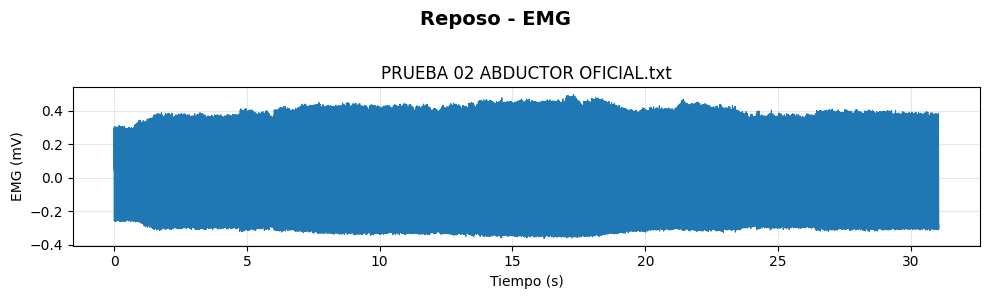

In [30]:
for nombre_grupo, lista_archivos in ARCHIVOS.items():
    print(f"\nGrupo: {nombre_grupo} ({len(lista_archivos)} archivo(s))")
    graficar_grupo(nombre_grupo, lista_archivos, CANAL, CARPETA_DATOS,
                   mostrar_crudo=MOSTRAR_CRUDO, carpeta_salida=CARPETA_SALIDA)
    plt.show()


Grupo (FFT): Movimiento con fuerza contraria (3 archivo(s))
  -> Figura FFT guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones LAB3 (EMG)/Abductor pollicis brevis (thumb)/figuras_bitalino2/movimiento_con_fuerza_contraria_fft.png


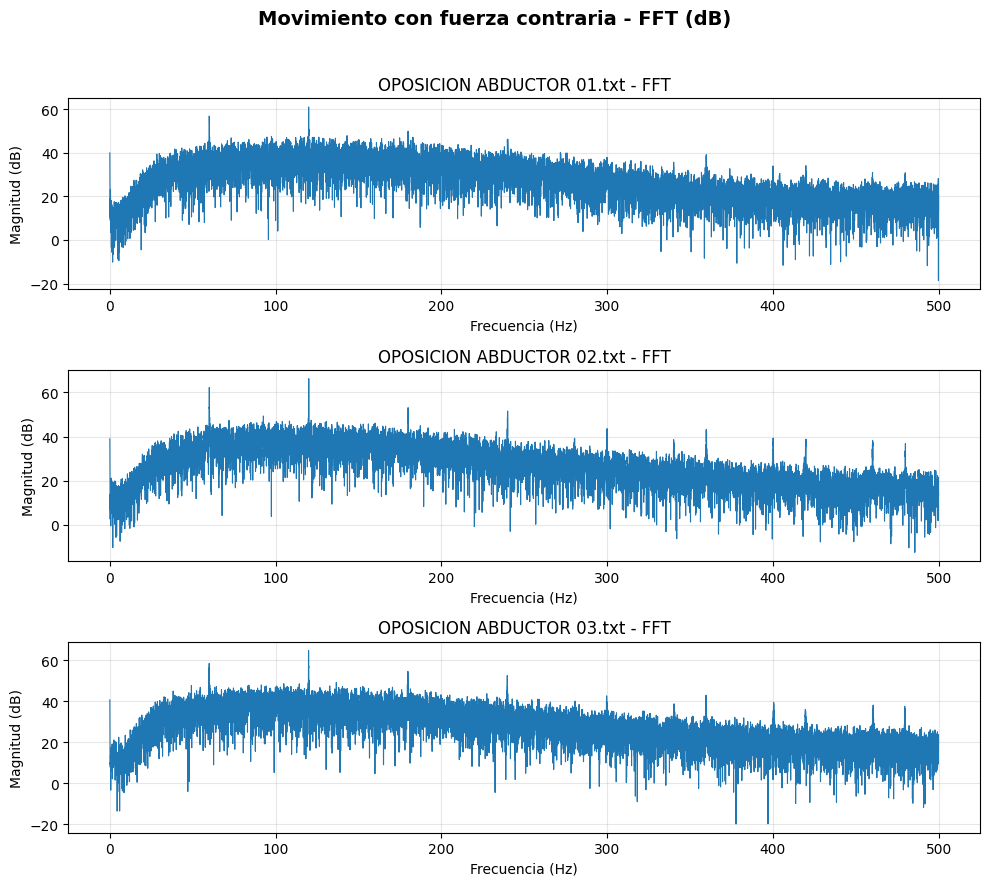


Grupo (FFT): Movimiento leve (3 archivo(s))
  -> Figura FFT guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones LAB3 (EMG)/Abductor pollicis brevis (thumb)/figuras_bitalino2/movimiento_leve_fft.png


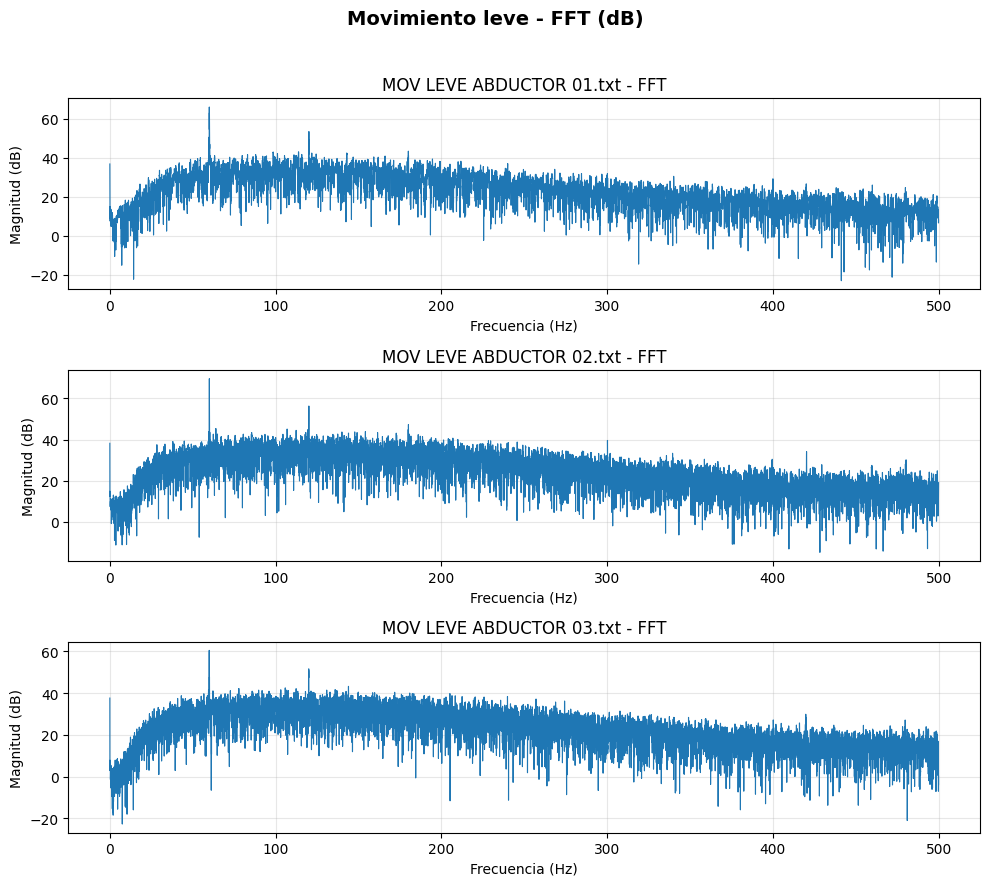


Grupo (FFT): Reposo (1 archivo(s))
  -> Figura FFT guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones LAB3 (EMG)/Abductor pollicis brevis (thumb)/figuras_bitalino2/reposo_fft.png


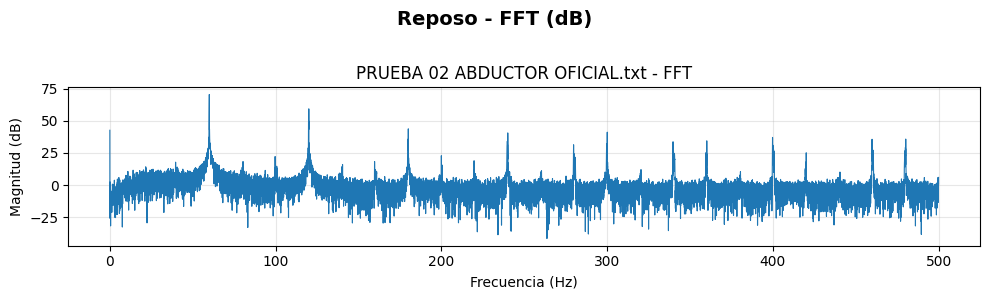

  -> Figura FFT guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones LAB3 (EMG)/Abductor pollicis brevis (thumb)/figuras_bitalino2/comparacion_general_fft.png


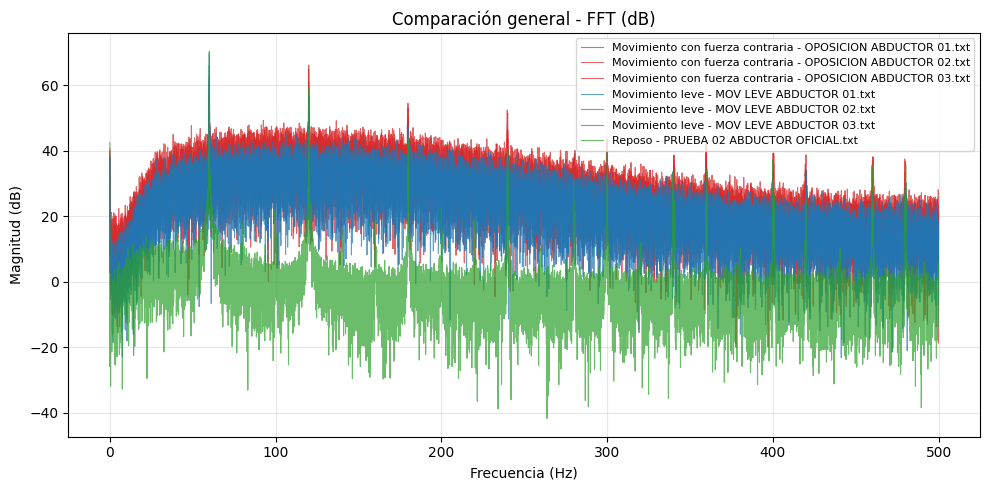

In [31]:
for nombre_grupo, lista_archivos in ARCHIVOS.items():
    print(f"\nGrupo (FFT): {nombre_grupo} ({len(lista_archivos)} archivo(s))")
    graficar_fft_grupo(nombre_grupo, lista_archivos, CANAL, CARPETA_DATOS, carpeta_salida=CARPETA_SALIDA)
    plt.show()

graficar_fft_comparacion_general(ARCHIVOS, CANAL, CARPETA_DATOS, carpeta_salida=CARPETA_SALIDA)
plt.show()

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones LAB3 (EMG)/Abductor pollicis brevis (thumb)/figuras_bitalino2/comparacion_general.png


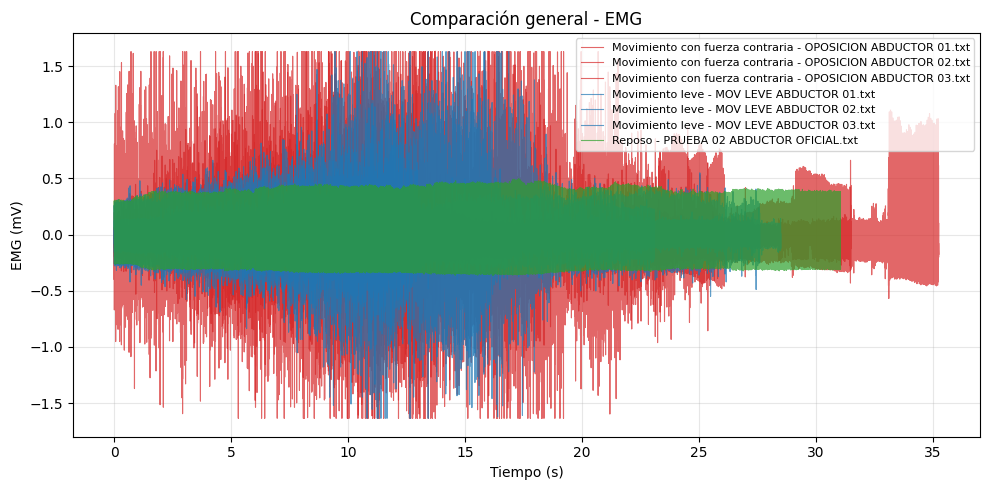

In [32]:
graficar_comparacion_general(ARCHIVOS, CANAL, CARPETA_DATOS,
                              carpeta_salida=CARPETA_SALIDA)
plt.show()